### Porcentaje de puntos podados con reordenaciones
Versión antigua que usaba permutaciones, se mantienen las gráficas de distribución de claves con los reordenamientos separados de coordenadas esféricas y cilíndricas.

### Distribuciones de las podas

In [21]:
def plot_key_distribution(csv_path: str, save: bool = False) -> None:
    df = pd.read_csv(csv_path)
    dataset_name = Path(csv_path).stem

    # Para cada hoja nos quedamos con la mejor clave
    best = df.loc[df.groupby(['leaf', 'kernel', 'mode', 'radius'])['count'].idxmin()].copy()

    key_names = {0: 'K0 (Azimuthal)', 1: 'K1 (Rxy/Theta)', 2: 'K2 (Z/R)'}
    key_colors = {0: '#4472C4', 1: '#2E8B57', 2: '#90EE90'}

    best['pct_pruned'] = (1 - best['count'] / best['total']) * 100
    pruned = best[best['pct_pruned'] > 0]
    modes   = pruned['mode'].unique()
    kernels = sorted(pruned['kernel'].unique())
    radii   = sorted(pruned['radius'].unique())

    for mode in modes:
        df_mode = pruned[pruned['mode'] == mode]

        fig, axes = plt.subplots(1, len(kernels),
                                  figsize=(5 * len(kernels), 5),
                                  sharey=True)
        if len(kernels) == 1:
            axes = [axes]

        for ax, kernel in zip(axes, kernels):
            df_k = df_mode[df_mode['kernel'] == kernel]

            # Contar hojas por clave y radio
            counts = (
                df_k.groupby(['radius', 'key'])
                .size()
                .unstack(fill_value=0)
                .reindex(columns=[0, 1, 2], fill_value=0)
            )
            # Normalizar a porcentaje
            pcts = counts.div(counts.sum(axis=1), axis=0) * 100

            bottom = np.zeros(len(radii))
            x = np.arange(len(radii))

            for key_id in [0, 1, 2]:
                vals = [pcts.loc[r, key_id] if r in pcts.index else 0 for r in radii]
                bars = ax.bar(x, vals, bottom=bottom,
                              label=key_names[key_id],
                              color=key_colors[key_id],
                              edgecolor='white', linewidth=0.5)
                # Etiqueta dentro de la barra si hay espacio
                for bar, val, bot in zip(bars, vals, bottom):
                    if val > 5:
                        ax.text(bar.get_x() + bar.get_width() / 2,
                                bot + val / 2,
                                f'{val:.1f}%',
                                ha='center', va='center',
                                fontsize=8, color='white', fontweight='bold')
                bottom += np.array(vals)

            ax.set_xticks(x)
            ax.set_xticklabels([f'r={r}' for r in radii], fontsize=9)
            ax.set_xlabel('Radio de búsqueda', fontsize=10)
            ax.set_title(kernel.upper(), fontsize=12, fontweight='bold')
            ax.set_ylim(0, 100)
            ax.set_ylabel('% hojas' if ax == axes[0] else '', fontsize=11)
            ax.grid(axis='y', alpha=0.2)
            ax.spines[['top', 'right']].set_visible(False)

            if ax == axes[0]:
                ax.legend(fontsize=8, loc='upper right')

        fig.suptitle(
            f'Distribución de clave elegida por hoja\n'
            f'Dataset: {dataset_name}   Modo: {mode}',
            fontsize=13, fontweight='bold', y=1.02)
        plt.show()
        if (save):
            out_path = Path(csv_path).parent / f'{dataset_name}_{mode}_key_distribution.png'
            plt.tight_layout()
            plt.savefig(out_path, dpi=150, bbox_inches='tight')
            plt.close()
            print(f'Guardado: {out_path}')

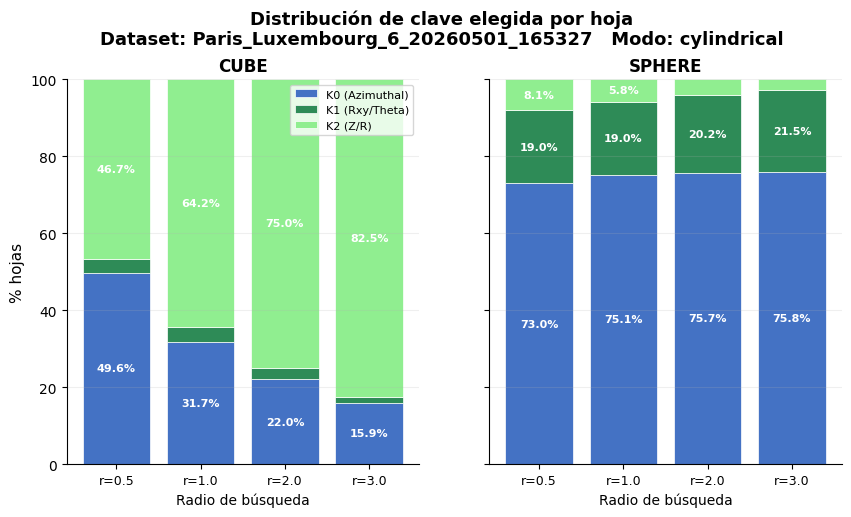

Guardado: outv1.2-ranges\Paris_Luxembourg_6_20260501_165327_cylindrical_key_distribution.png


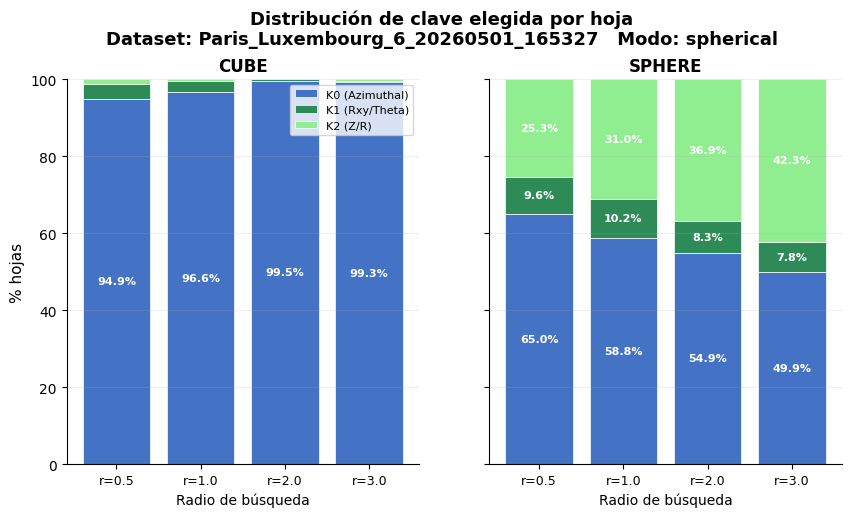

Guardado: outv1.2-ranges\Paris_Luxembourg_6_20260501_165327_spherical_key_distribution.png


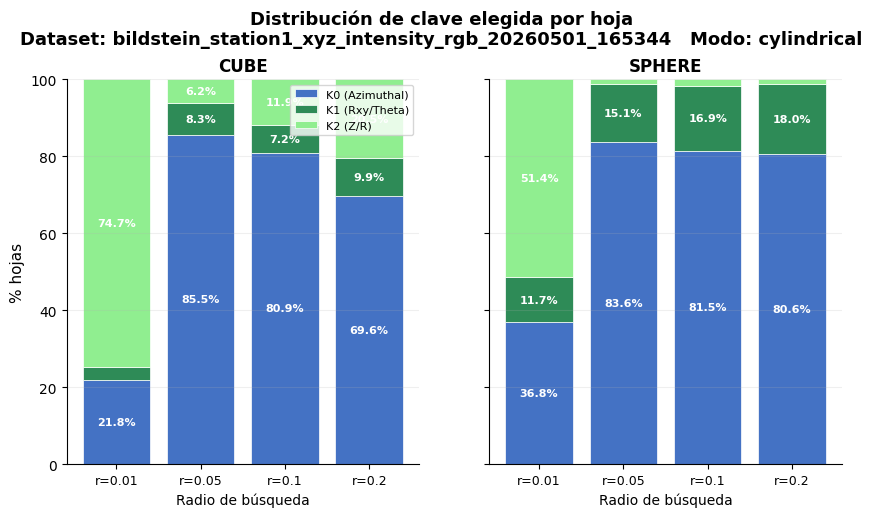

Guardado: outv1.2-ranges\bildstein_station1_xyz_intensity_rgb_20260501_165344_cylindrical_key_distribution.png


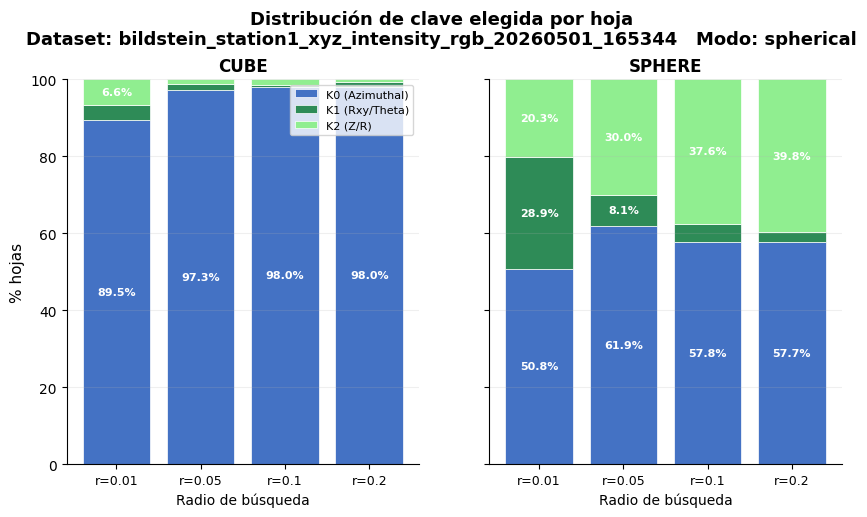

Guardado: outv1.2-ranges\bildstein_station1_xyz_intensity_rgb_20260501_165344_spherical_key_distribution.png


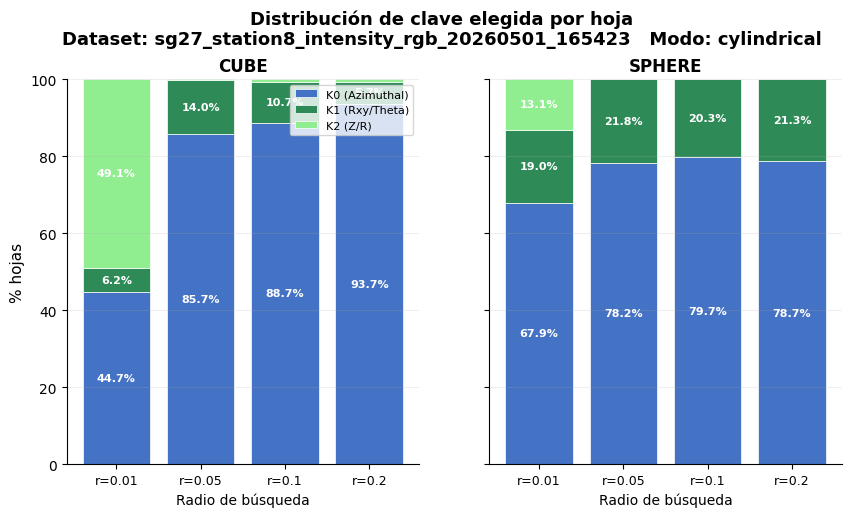

Guardado: outv1.2-ranges\sg27_station8_intensity_rgb_20260501_165423_cylindrical_key_distribution.png


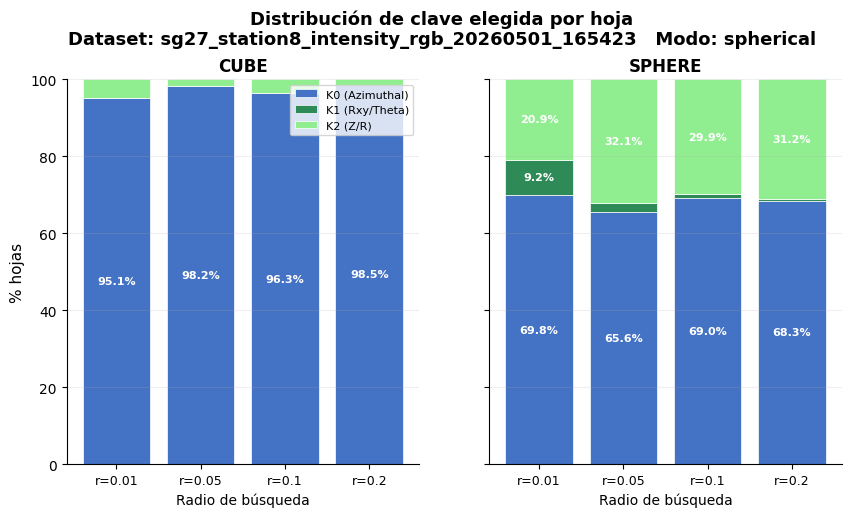

Guardado: outv1.2-ranges\sg27_station8_intensity_rgb_20260501_165423_spherical_key_distribution.png


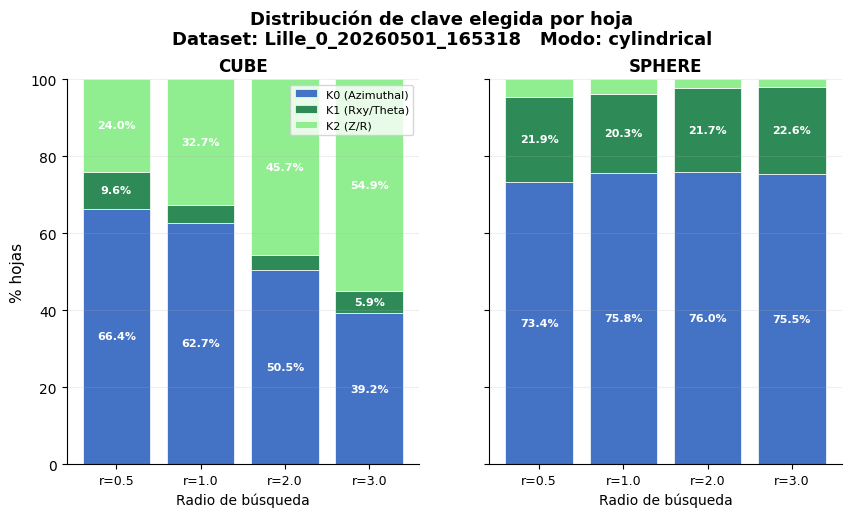

Guardado: outv1.2-ranges\Lille_0_20260501_165318_cylindrical_key_distribution.png


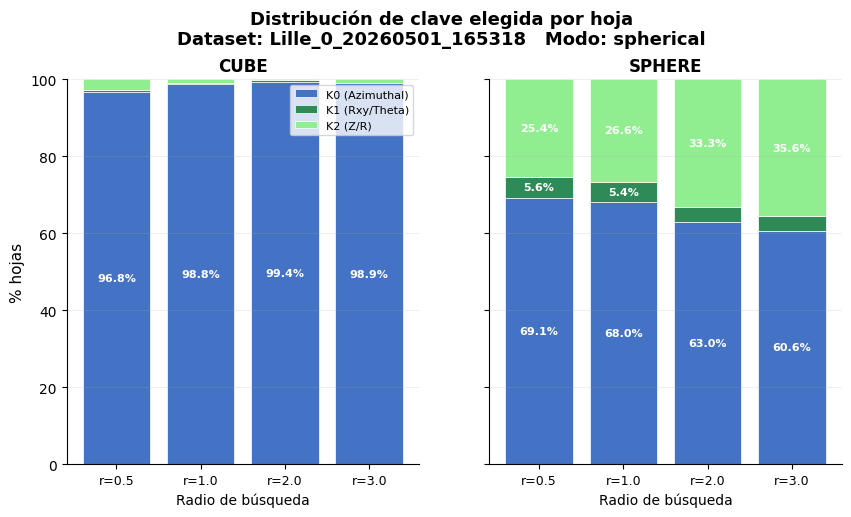

Guardado: outv1.2-ranges\Lille_0_20260501_165318_spherical_key_distribution.png


In [ ]:
for log in Path('outv1.2-ranges').glob('*.log'):
        plot_key_distribution(log, save=True)